In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:/Users/Rahul/OneDrive/Documents/corona_virus.csv")

In [3]:
df

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1,0,0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14,0,0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6,0,0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1,0,0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0,0,0
...,...,...,...,...,...,...,...,...
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,30-05-2021 04:20,102641,2335,95289
306425,306426,05/29/2021,Zeeland,Netherlands,30-05-2021 04:20,29147,245,0
306426,306427,05/29/2021,Zhejiang,Mainland China,30-05-2021 04:20,1364,1,1324
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,30-05-2021 04:20,87550,1738,83790


## 1.What is the total number of confirmed cases worldwide?

In [4]:
latest_date = df['Last Update'].max()

total_confirmed = df[df['Last Update'] == latest_date]['Confirmed'].sum()

print("Total Confirmed Cases Worldwide:", total_confirmed)

Total Confirmed Cases Worldwide: 857474


## 2.How many deaths have been reported globally?

In [5]:
total_deaths = df['Deaths'].sum()
print(total_deaths)

624013017


## 3.What is the total number of recovered cases worldwide? 

In [6]:
df['Recovered'].sum()

15450237912

## 4.How many countries/regions are represented in the dataset? 

In [7]:
num_countries = df['Country/Region'].nunique()

print("Number of Countries/Regions:", num_countries)

Number of Countries/Regions: 229


## 5.Which province/state has reported the highest number of confirmed cases?

In [8]:
result = df.groupby('Province/State')['Confirmed'].sum().reset_index()

highest = result.loc[result['Confirmed'].idxmax()]

print(highest)

Province/State    California
Confirmed          696898013
Name: 88, dtype: object


## 6.Which country/region has the highest number of deaths?

In [9]:
result = df.groupby('Country/Region')['Deaths'].sum().reset_index()

highest = result.loc[result['Deaths'].idxmax()]

print(highest)

Country/Region           US
Deaths            123303762
Name: 214, dtype: object


## 7.How does the number of confirmed cases vary across different provinces/states? 

In [10]:
province_cases = (
    df.groupby('Province/State')['Confirmed']
      .sum()
      .sort_values(ascending=False)
)

print(province_cases)

Province/State
California               696898013
Maharashtra              681186928
England                  666227518
Texas                    552039886
Sao Paulo                521308945
                           ...    
American Samoa                   0
Jervis Bay Territory             0
Recovered                        0
Montgomery County, TX            0
External territories             0
Name: Confirmed, Length: 736, dtype: int64


## 8.What is the trend of deaths over time globally? 

           Last Update   Deaths
0     01-04-2020 22:04    47363
1     01-05-2020 02:32   234577
2     01-05-2021 04:20  3180403
3     02-01-2020 01:52        4
4     02-01-2020 02:13        0
...                ...      ...
1900  29-05-2021 04:20  3523117
1901  30-04-2020 02:32   228935
1902  30-04-2021 04:21  3166125
1903  30-05-2021 04:20  3533619
1904  31-03-2020 23:49    42183

[1905 rows x 2 columns]


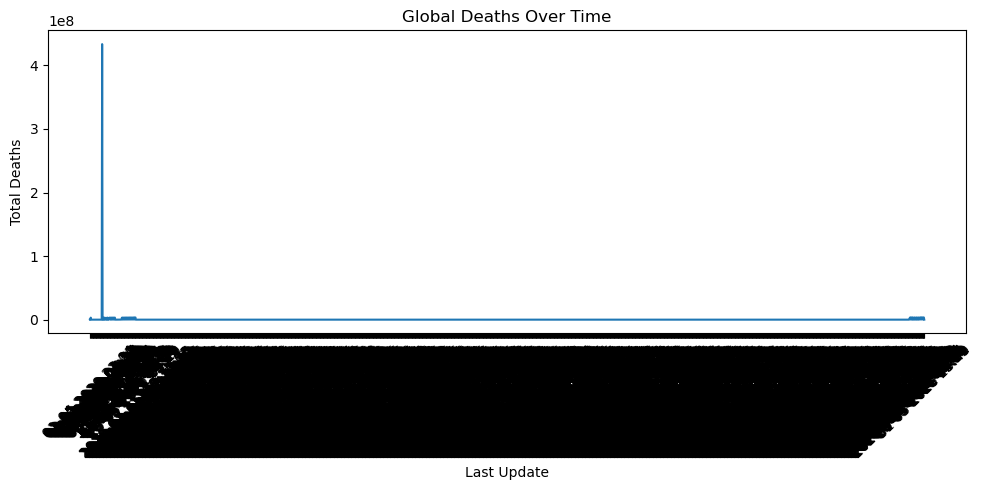

In [11]:
death_trend = df.groupby('Last Update')['Deaths'].sum().reset_index()

print(death_trend)

# Plot the trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(death_trend['Last Update'], death_trend['Deaths'])
plt.title('Global Deaths Over Time')
plt.xlabel('Last Update')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9.Which country/region has the highest number of recovered cases? 

In [12]:
highest_recovered = (
    df.groupby('Country/Region')['Recovered']
      .sum()
      .sort_values(ascending=False)
)

print(highest_recovered.head(1))

Country/Region
India    2900589824
Name: Recovered, dtype: int64


## 10.How does the number of recovered cases vary across different countries/regions? 

In [13]:
recovered_cases = (
    df.groupby('Country/Region')['Recovered']
      .sum()
      .sort_values(ascending=False)
)

print(recovered_cases)

Country/Region
India                             2900589824
Brazil                            2313677028
Russia                             790705716
Turkey                             564170558
US                                 503370956
                                     ...    
Puerto Rico                                0
Republic of Ireland                        0
Republic of the Congo                      0
Reunion                                    0
occupied Palestinian territory             0
Name: Recovered, Length: 229, dtype: int64


## 11.What is the distribution of confirmed cases by country/region?

In [14]:
confirmed_distribution = (
    df.groupby('Country/Region')['Confirmed']
      .sum()
      .sort_values(ascending=False)
)

print(confirmed_distribution)

Country/Region
US                       6049145667
India                    3226768088
Brazil                   2653587540
Russia                    930548849
France                    855188962
                            ...    
Cape Verde                        1
The Gambia                        1
Republic of the Congo             1
 Azerbaijan                       1
China                             0
Name: Confirmed, Length: 229, dtype: int64


## 12.Is there a correlation between the number of confirmed cases and deaths?

In [15]:
correlation = df['Confirmed'].corr(df['Deaths'])

print("Correlation between Confirmed cases and Deaths:", correlation)

Correlation between Confirmed cases and Deaths: 0.8884159872096521


## 13.Is there a correlation between the number of confirmed cases and recovered cases? 

In [16]:
correlation = df['Confirmed'].corr(df['Recovered'])

print("Correlation between Confirmed cases and Recovered cases:", correlation)

Correlation between Confirmed cases and Recovered cases: 0.633479300146205


## 14..How does the mortality rate vary across different countries/regions?

In [17]:
mortality_rate = (
    df.groupby('Country/Region')[['Confirmed', 'Deaths']]
      .sum()
)

mortality_rate['Mortality_Rate (%)'] = (
    mortality_rate['Deaths'] / mortality_rate['Confirmed']
) * 100

mortality_rate = mortality_rate.sort_values(
    by='Mortality_Rate (%)', ascending=False
)

print(mortality_rate[['Mortality_Rate (%)']])

                                Mortality_Rate (%)
Country/Region                                    
Yemen                                    24.698202
MS Zaandam                               22.175732
Vanuatu                                   9.605911
Mexico                                    9.339609
Sudan                                     6.403038
...                                            ...
Macau                                     0.000000
('St. Martin',)                           0.000000
Kiribati                                  0.000000
occupied Palestinian territory            0.000000
China                                          NaN

[229 rows x 1 columns]


## 15.How does the recovery rate vary across different countries/regions? 

In [18]:
recovery_rate = (
    df.groupby('Country/Region')[['Confirmed', 'Recovered']]
      .sum()
)

recovery_rate['Recovery_Rate (%)'] = (
    recovery_rate['Recovered'] / recovery_rate['Confirmed']
) * 100

recovery_rate = recovery_rate.sort_values(
    by='Recovery_Rate (%)', ascending=False
)

print(recovery_rate[['Recovery_Rate (%)']])

                                Recovery_Rate (%)
Country/Region                                   
Uzbekistan                              94.723025
Ghana                                   94.234364
Diamond Princess                        94.039209
Micronesia                              93.798450
Iceland                                 93.764480
...                                           ...
Republic of Ireland                      0.000000
Republic of the Congo                    0.000000
Reunion                                  0.000000
occupied Palestinian territory           0.000000
China                                         NaN

[229 rows x 1 columns]


## 16.What is the trend of new confirmed cases over time globally? 

           Last Update  New_Confirmed_Cases
0     01-04-2020 22:04                  0.0
1     01-05-2020 02:32            2326765.0
2     01-05-2021 04:20          148140275.0
3     02-01-2020 01:52         -151398296.0
4     02-01-2020 02:13              -1156.0
...                ...                  ...
1900  29-05-2021 04:20           19847861.0
1901  30-04-2020 02:32         -166274819.0
1902  30-04-2021 04:21          147324560.0
1903  30-05-2021 04:20           19431094.0
1904  31-03-2020 23:49         -169094086.0

[1905 rows x 2 columns]


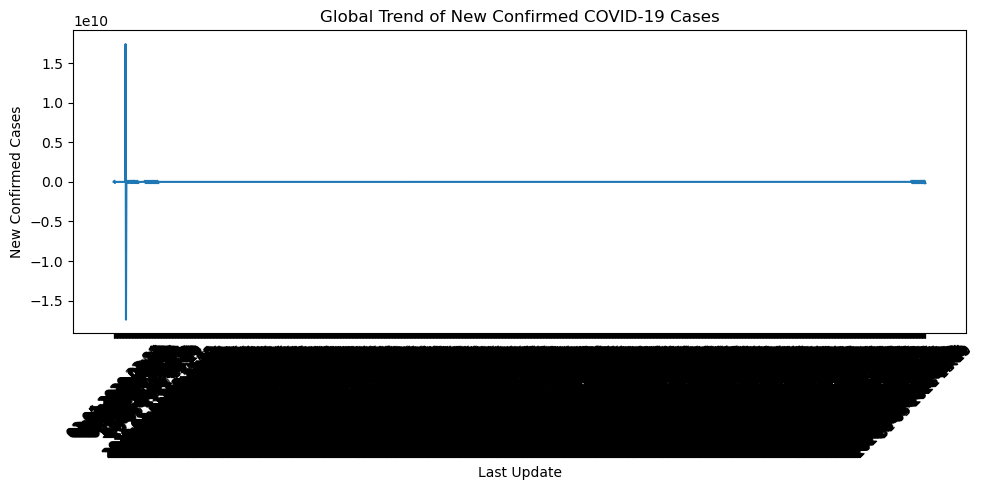

In [19]:
new_confirmed = (
    df.groupby('Last Update')['Confirmed']
      .sum()
      .diff()                
      .fillna(0)
      .reset_index(name='New_Confirmed_Cases')
)

print(new_confirmed)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(new_confirmed['Last Update'], new_confirmed['New_Confirmed_Cases'])
plt.title('Global Trend of New Confirmed COVID-19 Cases')
plt.xlabel('Last Update')
plt.ylabel('New Confirmed Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17.How does the fatality rate vary across different provinces/states?

In [20]:
fatality_rate = (
    df.groupby('Province/State')[['Confirmed', 'Deaths']]
      .sum()
)

fatality_rate['Fatality_Rate (%)'] = (
    fatality_rate['Deaths'] / fatality_rate['Confirmed']
) * 100

fatality_rate = fatality_rate.sort_values(
    by='Fatality_Rate (%)', ascending=False
)

print(fatality_rate[['Fatality_Rate (%)']])

                       Fatality_Rate (%)
Province/State                          
Unknown                        54.427525
Santa Rosa County, FL          40.000000
Lee County, FL                 33.333333
King County, WA                22.087379
Placer County, CA              21.428571
...                                  ...
American Samoa                       NaN
External territories                 NaN
Jervis Bay Territory                 NaN
Montgomery County, TX                NaN
Recovered                            NaN

[736 rows x 1 columns]


## 18.How does the recovery rate vary across different provinces/states? 

In [21]:
recovery_rate = (
    df.groupby('Province/State')[['Confirmed', 'Recovered']]
      .sum()
)

recovery_rate['Recovery_Rate (%)'] = (
    recovery_rate['Recovered'] / recovery_rate['Confirmed']
) * 100

recovery_rate = recovery_rate.sort_values(
    by='Recovery_Rate (%)', ascending=False
)

print(recovery_rate[['Recovery_Rate (%)']])

                                              Recovery_Rate (%)
Province/State                                                 
Recovered                                                   inf
US                                                 1.330000e+04
Unknown                                            7.937735e+03
Repatriated Travellers                             1.000000e+02
Saint Helena, Ascension and Tristan da Cunha       9.784580e+01
...                                                         ...
Zuid-Holland                                       0.000000e+00
American Samoa                                              NaN
External territories                                        NaN
Jervis Bay Territory                                        NaN
Montgomery County, TX                                       NaN

[736 rows x 1 columns]


## 19.What is the trend of active cases over time globally? 

           Last Update    Active
0     01-04-2020 22:04    691748
1     01-05-2020 02:32   2009526
2     01-05-2021 04:20  59982126
3     02-01-2020 01:52      1161
4     02-01-2020 02:13        28
...                ...       ...
1900  29-05-2021 04:20  59314539
1901  30-04-2020 02:32   1994053
1902  30-04-2021 04:21  59803986
1903  30-05-2021 04:20  59277272
1904  31-03-2020 23:49    637284

[1905 rows x 2 columns]


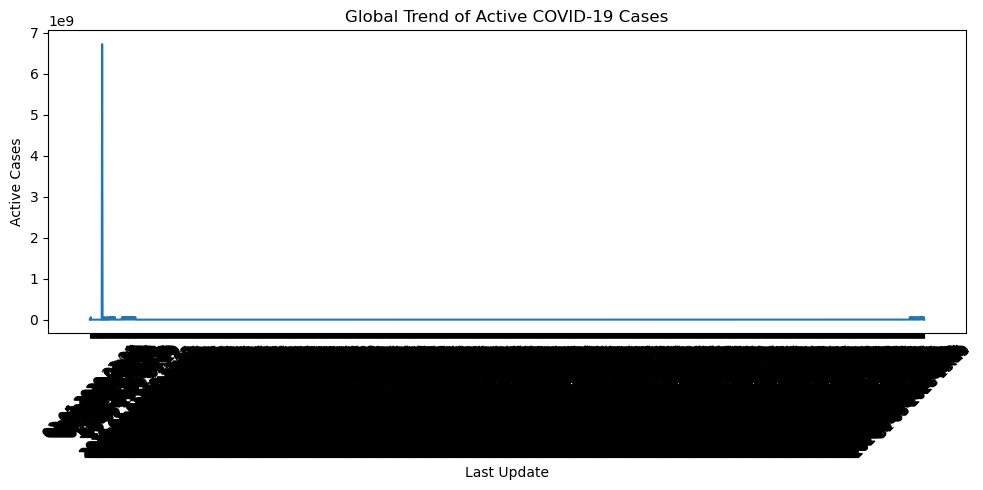

In [22]:
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']

active_trend = (
    df.groupby('Last Update')['Active']
      .sum()
      .reset_index()
)

print(active_trend)

# Plot the trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(active_trend['Last Update'], active_trend['Active'])
plt.title('Global Trend of Active COVID-19 Cases')
plt.xlabel('Last Update')
plt.ylabel('Active Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. What is the trend of confirmed cases over time globally? 

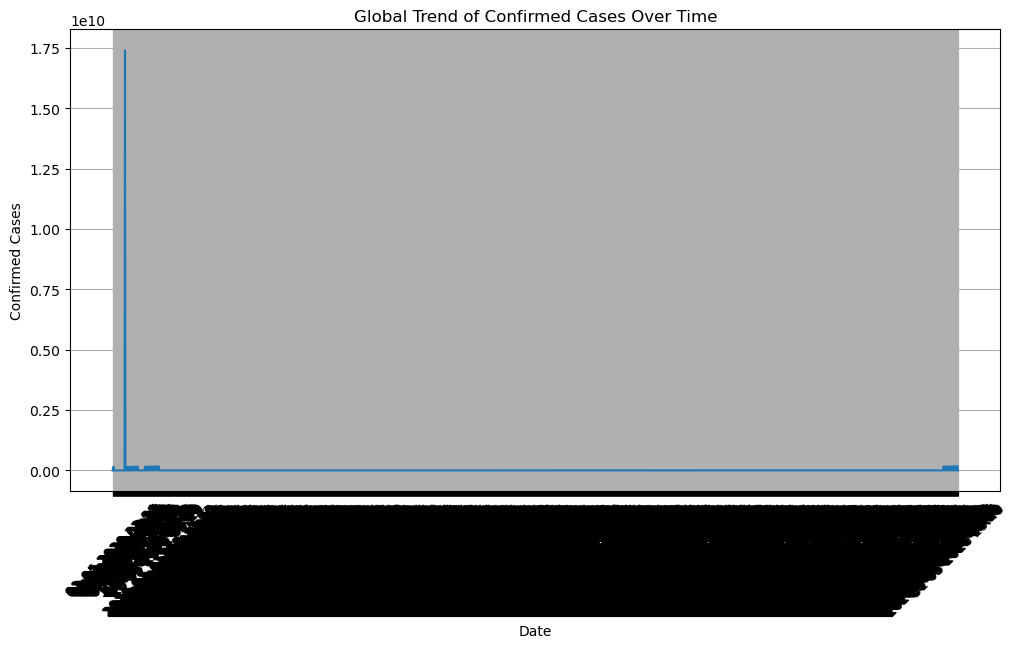

In [24]:
global_confirmed = df.groupby('Last Update')['Confirmed'].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(global_confirmed['Last Update'], global_confirmed['Confirmed'])
plt.title("Global Trend of Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()